In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("reddit_stocks_sentiment.csv")

print(data.columns)
data.head()

Index(['title', 'body', 'created_utc', 'upvotes', 'num_comments',
       'cleaned_title', 'cleaned_body', 'title_sentiment', 'body_sentiment'],
      dtype='object')


,title,body,created_utc,upvotes,num_comments,cleaned_title,cleaned_body,title_sentiment,body_sentiment
0,Is the Moonshot app where you trade meme coins...,So my siblings got on this app and supposedly ...,1.732083e+09,0,10,moonshot app trade meme coins legit,siblings got app supposedly struck gold meme c...,0.0,0.816667
1,I am going to explain to Stop using fundamenta...,"First, id like to state the fact that do you g...",1.732082e+09,0,9,going explain stop using fundamentals sub use ...,first id like state fact guys recall amount ro...,0.0,0.075848
2,Trading SPY for gains,"First time posting, long time lurking.\n\nI ha...",1.732080e+09,2,7,trading spy gains,first time posting long time lurking money k s...,0.0,0.030808
3,Okta - my analysis and thoughts,I'd appreciate any and all feedback to see if ...,1.732062e+09,8,5,okta analysis thoughts,id appreciate feedback see feel im track persp...,0.0,0.137140
4,Comcast will announce the spinoff of cable net...,Comcast is moving forward with the spinoff of ...,1.732061e+09,100,39,comcast announce spinoff cable networks wednes...,comcast moving forward spinoff cable network c...,0.0,0.125000


In [3]:
data['text'] = data['cleaned_title'].astype(str) + " " + data['cleaned_body'].astype(str)

In [4]:
data['sentiment'] = (data['title_sentiment'] + data['body_sentiment']) / 2

In [5]:
# Slightly relaxed threshold (better data balance)
data = data[(data['sentiment'] > 0.05) | (data['sentiment'] < -0.05)]

data = data.reset_index(drop=True)

data['label'] = data['sentiment'].apply(lambda x: 1 if x > 0 else 0)

print(data['label'].value_counts())

label
1    402
0     68
Name: count, dtype: int64


In [6]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english'
)

X_tfidf = vectorizer.fit_transform(data['text']).toarray()

tfidf_df = pd.DataFrame(
    X_tfidf,
    columns=vectorizer.get_feature_names_out()
)

In [7]:
features = pd.concat([
    tfidf_df,
    data[['upvotes', 'num_comments', 'sentiment']]
], axis=1)

In [8]:
X = features
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures both classes present
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
def build_model(input_dim):
    inputs = Input(shape=(input_dim,))
    
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, output)
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1003)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         128,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,881 (542.50 KB)

 Trainable params: 138,881 (542.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8457 - loss: 0.4824 - val_accuracy: 0.8511 - val_loss: 0.4582
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8590 - loss: 0.3013 - val_accuracy: 0.8511 - val_loss: 0.4312
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8803 - loss: 0.2279 - val_accuracy: 0.8511 - val_loss: 0.4182
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9574 - loss: 0.1416 - val_accuracy: 0.8404 - val_loss: 0.4453
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9840 - loss: 0.0711 - val_accuracy: 0.8404 - val_loss: 0.4777
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0299 - val_accuracy: 0.8404 - val_loss: 0.5085
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 0.8298 - val_loss: 0.5372
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.8298 - v

In [12]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [13]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(classification_report(y_test, y_pred))

RMSE: 0.41256849850351734
              precision    recall  f1-score   support

           0       0.25      0.07      0.11        14
           1       0.86      0.96      0.91        80

    accuracy                           0.83        94
   macro avg       0.55      0.52      0.51        94
weighted avg       0.77      0.83      0.79        94



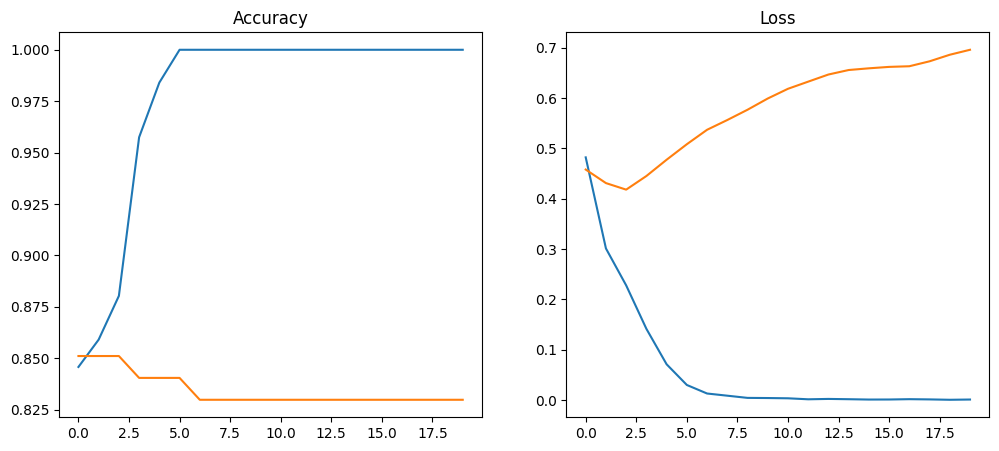

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")

plt.show()